In [27]:
import numpy as np
rng = np.random.default_rng(seed=42)
m=200
X = 6 * rng.standard_normal((m,1)) - 3
y = X ** 2 + X + rng.standard_normal((m,1))


(0.0, 10.0)

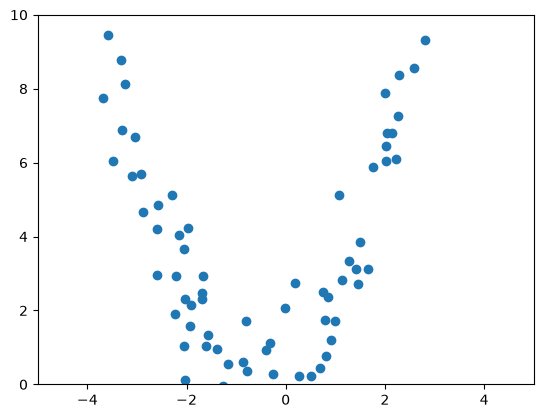

In [28]:
import matplotlib.pyplot as plt 
plt.scatter(X,y)
plt.xlim((-5,5))
plt.ylim((0,10))

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly_feat = PolynomialFeatures(include_bias=False,degree=2)
X_poly_feat = poly_feat.fit_transform(X)
X[0:5]


array([[ -1.17169752],
       [ -9.23990464],
       [  1.50270717],
       [  2.6433883 ],
       [-14.70621113]])

In [30]:
X_poly_feat[0:5]

array([[ -1.17169752,   1.37287508],
       [ -9.23990464,  85.37583771],
       [  1.50270717,   2.25812885],
       [  2.6433883 ,   6.9875017 ],
       [-14.70621113, 216.27264586]])

In [31]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly_feat,y)
print(f"Intercept:{lin_reg.intercept_}\nCoefficient:{lin_reg.coef_}")

Intercept:[-0.01448483]
Coefficient:[[0.98455012 0.99961543]]


In [32]:
X_poly_feat

array([[-1.17169752e+00,  1.37287508e+00],
       [-9.23990464e+00,  8.53758377e+01],
       [ 1.50270717e+00,  2.25812885e+00],
       [ 2.64338830e+00,  6.98750170e+00],
       [-1.47062111e+01,  2.16272646e+02],
       [-1.08130770e+01,  1.16922635e+02],
       [-2.23295758e+00,  4.98609956e+00],
       [-4.89745555e+00,  2.39850709e+01],
       [-3.10080695e+00,  9.61500371e+00],
       [-8.11826357e+00,  6.59062033e+01],
       [ 2.27638785e+00,  5.18194164e+00],
       [ 1.66675161e+00,  2.77806094e+00],
       [-2.60381581e+00,  6.77985680e+00],
       [ 3.76344724e+00,  1.41635351e+01],
       [-1.94943946e-01,  3.80031423e-02],
       [-8.15575478e+00,  6.65163360e+01],
       [-7.87495296e-01,  6.20148840e-01],
       [-8.75329560e+00,  7.66201839e+01],
       [ 2.27070181e+00,  5.15608670e+00],
       [-3.29955547e+00,  1.08870663e+01],
       [-4.10917418e+00,  1.68853125e+01],
       [-7.08557727e+00,  5.02054052e+01],
       [ 4.33524803e+00,  1.87943755e+01],
       [-3.

(0.0, 10.0)

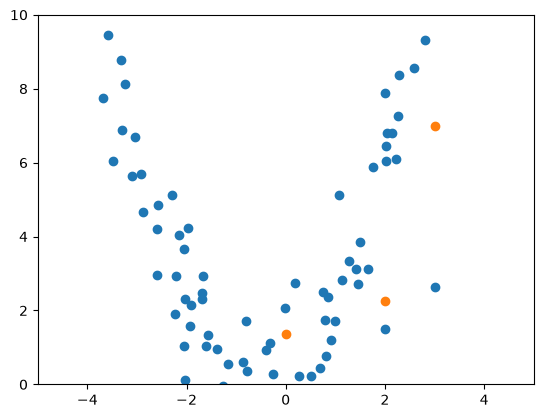

In [33]:
plt.scatter(X,y)
plt.plot(X_poly_feat,"o")
plt.xlim((-5,5))
plt.ylim((0,10))


In [77]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(),
                                                       X,
                                                       y,
                                                       train_sizes=np.linspace(0.01,1.0,40),
                                                       cv=5,
                                                       scoring="neg_root_mean_squared_error")
train_error = -train_scores.mean(axis=1)
valid_error = -valid_scores.mean(axis=1)

In [79]:
# train_error
-valid_scores.mean()

np.float64(39.83699884571231)

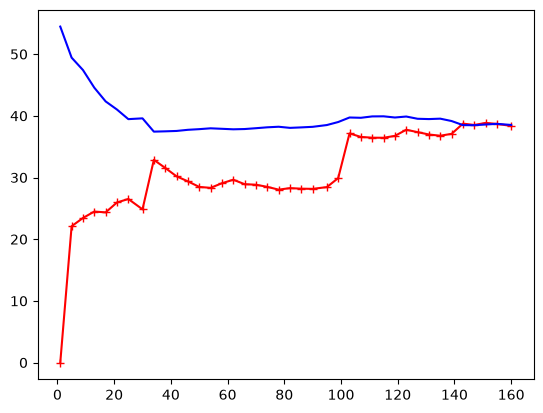

In [36]:
plt.plot(train_sizes, train_error, 'r-+')
plt.plot(train_sizes, valid_error, 'b-')

## **Model** *is Underfitting*

In [80]:
from sklearn.pipeline import make_pipeline

poly_reg = make_pipeline(PolynomialFeatures(degree=10,include_bias=False),LinearRegression())
train_sizes, train_scores, valid_scores = learning_curve(poly_reg,
                                                         X,
                                                         y,
                                                         train_sizes=np.linspace(0.01,1.0,40),
                                                         cv=5,
                                                         scoring='neg_root_mean_squared_error')


In [85]:
valid_scores.mean(axis=1)

array([-5.44658647e+01, -3.10652202e+06, -4.49995806e+05, -4.54900644e+03,
       -7.58397799e+03, -4.29072746e+03, -4.37085787e+03, -4.49301661e+03,
       -8.06982123e+02, -8.10147431e+02, -8.26569203e+02, -8.42843643e+02,
       -8.49699816e+02, -6.99467360e+02, -6.50144587e+02, -5.10339303e+02,
       -5.15208155e+02, -5.06572672e+02, -4.84041616e+02, -4.86524409e+02,
       -4.73939228e+02, -4.65703610e+02, -4.70747498e+02, -4.52882905e+02,
       -3.94251249e+02, -3.91128723e+02, -3.98245262e+02, -3.82122460e+02,
       -3.80840402e+02, -3.69981416e+02, -3.78638632e+02, -3.85036364e+02,
       -3.87172471e+02, -3.79503631e+02, -3.71854486e+02, -3.72757906e+02,
       -3.67708574e+02, -3.36435470e+02, -3.34609256e+02, -3.38085424e+02])

(0.0, 1000.0)

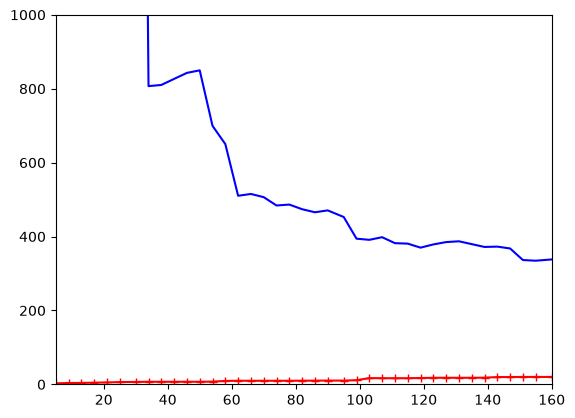

In [71]:
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes,train_errors,'r-+',label='Train')
plt.plot(train_sizes,valid_errors,'b-',label='Valid')
plt.xlim(5,160)
plt.ylim(0,1000)

In [ ]:
# rng = np.random.default_rng(seed=42)
# m = 20  # number of instances
# X = 3 * rng.random((m, 1))
# y = 1 + 0.5 * X + rng.standard_normal((m, 1)) / 1.5
# X_new = np.linspace(0, 3, 100).reshape(100, 1)

[Text(0, 0.0, ''),
 Text(0, 0.5, ''),
 Text(0, 1.0, ''),
 Text(0, 1.5, ''),
 Text(0, 2.0, ''),
 Text(0, 2.5, ''),
 Text(0, 3.0, ''),
 Text(0, 3.5, '')]

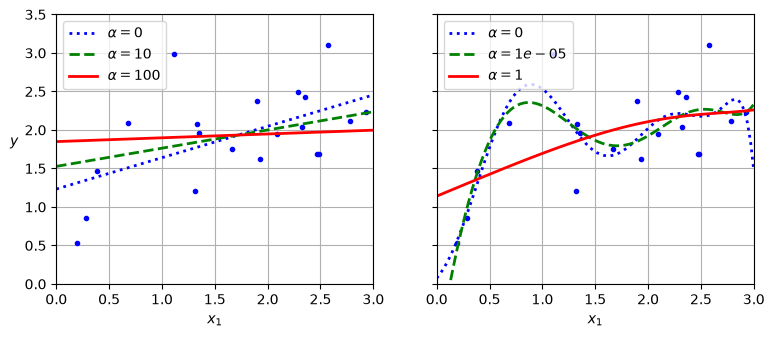

In [ ]:
# extra code – this cell generates Figure 4–17
from sklearn.preprocessing import StandardScaler
X_new = np.linspace(0, 3, 100).reshape(100, 1)
def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])

## **Ridge Regression**

In [87]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1,solver='cholesky')
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([16.0796866])

In [96]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty='l2',alpha=0.1/m,max_iter=1000,tol=None,eta0=0.01,random_state=42)
sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([1.83659707])

The penalty hyperparameter sets the type of regularization term to use. Specifying "l2" indicates that you want SGD to add a regularization term to the MSE cost function equal to alpha times the square of the ℓ2 norm of the weight vector. This is just like ridge regression, except there’s no division by m in this case; that’s why we passed alpha=0.1 / m, to get the same result as Ridge(alpha=0.1).


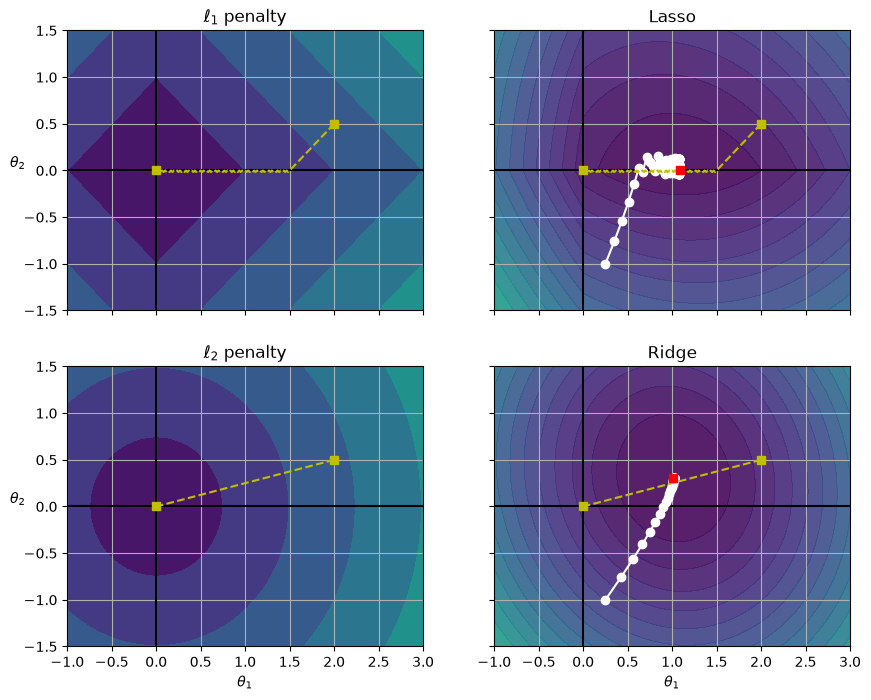

In [97]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

plt.show()

You can get a sense of why the ℓ1 norm induces sparsity by looking at Figure 4-20: the axes represent two model parameters, and the background contours represent different loss functions. In the top-left plot, the contours represent the ℓ1 loss (|θ1| + |θ2|), which drops linearly as you get closer to any axis. For example, if you initialize the model parameters to θ1 = 2 and θ2 = 0.5, running gradient descent will decrement both parameters equally (as represented by the dashed yellow line); therefore θ2 will reach 0 first (since it was closer to 0 to begin with). After that, gradient descent will roll down the gutter until it reaches θ1 = 0 (with a bit of bouncing around, since the gradients of ℓ1 never get close to 0: they are either –1 or 1 for each parameter). In the top-right plot, the contours represent lasso regression’s cost function (i.e., an MSE cost function plus an ℓ1 loss). The small white circles show the path that gradient descent takes to optimize some model parameters that were initialized around θ1 = 0.25 and θ2 = –1: notice again how the path quickly reaches θ2 = 0, then rolls down the gutter and ends up bouncing around the global optimum (represented by the red square). If we increased α, the global optimum would move left along the dashed yellow line, while if we decreased α, the global optimum would move right (in this example, the optimal parameters for the unregularized MSE are θ1 = 2 and θ2 = 0.5).

The two bottom plots show the same thing but with an ℓ2 penalty instead. In the bottom-left plot, you can see that the ℓ2 loss decreases as we get closer to the origin, so gradient descent just takes a straight path toward that point. In the bottom-right plot, the contours represent ridge regression’s cost function (i.e., an MSE cost function plus an ℓ2 loss). As you can see, the gradients get smaller as the parameters approach the global optimum, so gradient descent naturally slows down. This limits the bouncing around, which helps ridge converge faster than lasso regression. Also note that the optimal parameters (represented by the red square) get closer and closer to the origin when you increase α, but they never get eliminated entirely.



## **Lasso Regression**

In [98]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([1.87550211])

*Note that you could instead use SGDRegressor(penalty="l1", alpha=0.1)*

## **Elastic Net Regression**

In [99]:
from sklearn.linear_model import ElasticNet
elastic_net_reg = ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic_net_reg.fit(X,y)
elastic_net_reg.predict([[1.5]])

array([1.8645014])

## **Early Stopping**


In [ ]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

X_train, y_train, X_valid, y_valid = [...]  # split the quadratic dataset

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)